In [16]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import os

In [18]:
#set the dataset path to the variables
train_dataset_path = "/content/drive/MyDrive/Dataset/train/train"
test_dataset_path = "/content/drive/MyDrive/Dataset/test/test"

In [19]:
#Image Transformation as ResNet18 requires image to be 224 x 224
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [20]:
#Creating Custom Dataset Class
class DrivingDataset(Dataset):

    def __init__(self, data_path, label_column, transform=None):

        self.data_path = data_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(data_path, "labels.csv")
        )

        self.label_column = label_column

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = os.path.join(
            self.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        image = Image.open(img_path).convert("RGB")

        label = int(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [21]:
#Creating data set using the Class:
train_dataset = DrivingDataset(
    train_dataset_path,
    label_column='has_pedestrian',
    transform=transform
)
val_dataset = DrivingDataset(
    test_dataset_path,
    label_column='has_pedestrian',
    transform=transform
)

In [22]:
#Loads data in mini-batches.
#Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [25]:

#Loading ResNet18
#Already learned: edges, textures shapes from ImageNet
model = models.resnet18(pretrained=True)

In [26]:
#Modifying ResNet by replacing final layer
model.fc = nn.Linear(
    model.fc.in_features,
    1
)

In [27]:
#Loss Function
criterion = nn.BCEWithLogitsLoss()


In [28]:
#Adam Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [29]:
#Move Model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [30]:
#Traning Loop
num_epochs = 5
train_loss_data = []
val_loss_data = []
for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_train_loss = 0

    for batch_idx, (images, labels_batch) in enumerate(train_loader):
        print(f"Batch {batch_idx+1}/{len(train_loader)}")

        images = images.to(device)
        labels_batch = labels_batch.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    train_loss_data.append(avg_train_loss)

    # VALIDATION
    model.eval()

    running_val_loss = 0

    with torch.no_grad():

        for images, labels_batch in val_loader:

            images = images.to(device)
            labels_batch = labels_batch.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels_batch)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    val_loss_data.append(avg_val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Training Loss: {avg_train_loss:.4f}")
    print(f"Validation Loss: {avg_val_loss:.4f}")


Batch 1/225
Batch 2/225
Batch 3/225
Batch 4/225
Batch 5/225
Batch 6/225
Batch 7/225
Batch 8/225
Batch 9/225
Batch 10/225
Batch 11/225
Batch 12/225
Batch 13/225
Batch 14/225
Batch 15/225
Batch 16/225
Batch 17/225
Batch 18/225
Batch 19/225
Batch 20/225
Batch 21/225
Batch 22/225
Batch 23/225
Batch 24/225
Batch 25/225
Batch 26/225
Batch 27/225
Batch 28/225
Batch 29/225
Batch 30/225
Batch 31/225
Batch 32/225
Batch 33/225
Batch 34/225
Batch 35/225
Batch 36/225
Batch 37/225
Batch 38/225
Batch 39/225
Batch 40/225
Batch 41/225
Batch 42/225
Batch 43/225
Batch 44/225
Batch 45/225
Batch 46/225
Batch 47/225
Batch 48/225
Batch 49/225
Batch 50/225
Batch 51/225
Batch 52/225
Batch 53/225
Batch 54/225
Batch 55/225
Batch 56/225
Batch 57/225
Batch 58/225
Batch 59/225
Batch 60/225
Batch 61/225
Batch 62/225
Batch 63/225
Batch 64/225
Batch 65/225
Batch 66/225
Batch 67/225
Batch 68/225
Batch 69/225
Batch 70/225
Batch 71/225
Batch 72/225
Batch 73/225
Batch 74/225
Batch 75/225
Batch 76/225
Batch 77/225
Batch 78

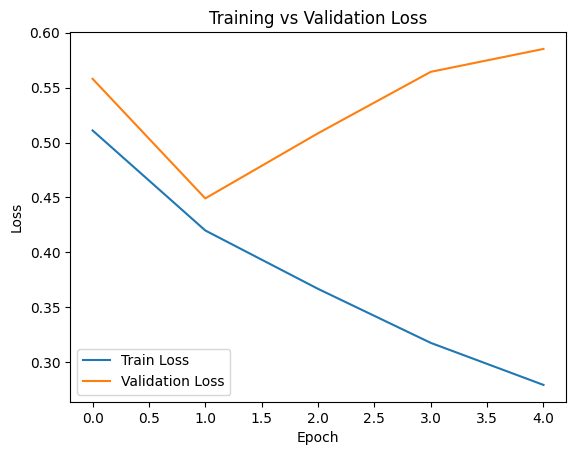

In [31]:
import matplotlib.pyplot as plt
plt.plot(train_loss_data, label="Train Loss")
plt.plot(val_loss_data, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

In [34]:
test_image_path = "/content/drive/MyDrive/Dataset/train/train/rgb-front/000080.jpg"

def predict_image(model, image_path, transform):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    # Show image
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    # Transform image
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        prediction = model(image_tensor)

        probability = prediction.item()

    print(f"Prediction Probability: {probability:.4f}")

    if probability >= 0.5:
        print("Detected: TRUE")
    else:
        print("Detected: FALSE")



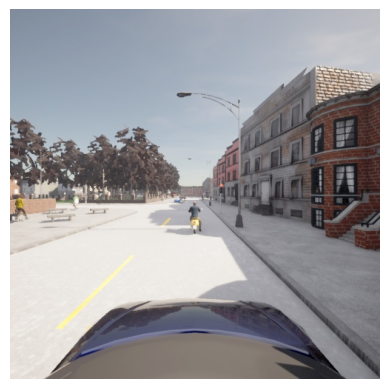

Prediction Probability: 7.4120
Detected: TRUE


In [35]:
predict_image(
    model,
    test_image_path,
    transform
)

In [36]:
IMAGE_DIR = os.path.join(train_dataset_path, "rgb-front")
def predict_with_ground_truth(model, dataframe, idx, label_column):

    row = dataframe.iloc[idx]

    frame = str(row["frame"]).zfill(6)

    image_path = os.path.join(IMAGE_DIR, f"{frame}.jpg")

    actual_label = row[label_column]

    model.eval()

    image = Image.open(image_path).convert("RGB")

    plt.imshow(image)
    plt.axis("off")
    plt.show()

    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        prediction = model(image_tensor)

        probability = prediction.item()

    predicted_label = 1 if probability >= 0.5 else 0

    print(f"Actual Label: {actual_label}")
    print(f"Predicted Label: {predicted_label}")
    print(f"Confidence: {probability:.4f}")

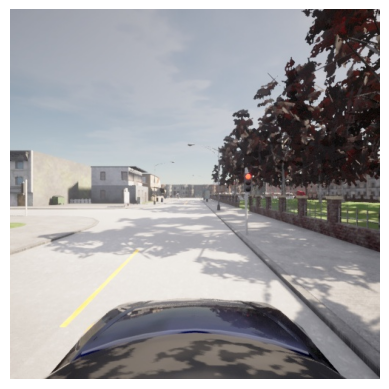

Actual Label: False
Predicted Label: 0
Confidence: -3.1202


In [37]:
df = pd.read_csv(
            os.path.join(test_dataset_path, "labels.csv")
        )
predict_with_ground_truth(
    model,
    df,
    idx=50,
    label_column="has_pedestrian"
)

In [38]:
#saving the model
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Dataset/pedestrian_model.pth"
)